# Customer Retention & RFM Analysis — Exploratory Data Analysis
## Business purpose: Visualise RFM findings to communicate
## customer behaviour patterns clearly to non-technical stakeholders.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Load all three datasets
rfm     = pd.read_csv("../Data/processed/rfm_segments.csv")
orders   = pd.read_csv("../Data/processed/online_retail_clean.csv")

In [5]:

print(orders.columns.tolist())
print(orders.dtypes)

['invoice', 'stockcode', 'description', 'quantity', 'invoicedate', 'price', 'customer_id', 'country', 'revenue']
invoice          int64
stockcode       object
description     object
quantity         int64
invoicedate     object
price          float64
customer_id      int64
country         object
revenue        float64
dtype: object


In [6]:
rfm 

,customer_id,last_purchase_date,first_purchase_date,Frequency,Monetary,avg_order_value,total_items,unique_products,Recency,tenure_days,R_Score,F_Score,M_Score,RFM_Total,Segment
0,12346,2011-01-18 10:01:00,2009-12-14 08:34:00,12,77556.46,2281.072353,74285,27,326,400,2,5,5,12,Cannot Lose Them
1,12347,2011-12-07 15:52:00,2010-10-31 14:20:00,8,4921.53,22.169054,2967,126,2,402,5,4,5,14,Champions
2,12348,2011-09-25 13:13:00,2010-09-27 14:59:00,5,2019.40,39.596078,2714,25,75,362,3,4,4,11,Loyal Customers
3,12349,2011-11-21 09:51:00,2010-04-29 13:20:00,4,4428.69,25.306800,1624,138,19,570,5,3,5,13,Loyal Customers
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,19.670588,197,17,310,0,2,1,2,5,About to Sleep
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5873,18283,2011-12-06 12:02:00,2010-02-19 17:16:00,22,2664.90,2.841045,1679,352,4,654,5,5,4,14,Champions
5874,18284,2010-10-04 11:33:00,2010-10-04 11:33:00,1,461.68,16.488571,494,28,432,0,1,2,2,5,About to Sleep
5875,18285,2010-02-17 10:24:00,2010-02-17 10:24:00,1,427.00,35.583333,145,12,661,0,1,2,2,5,About to Sleep
5876,18286,2010-08-20 11:57:00,2009-12-16 10:45:00,2,1296.43,19.349701,608,67,477,247,1,3,4,8,At Risk


In [7]:
# Confirm loads
print(f"RFM segments:  {len(rfm):,} customers, {rfm['Segment'].nunique()} segments")
print(f"Orders:        {len(orders):,} transactions")

RFM segments:  5,878 customers, 11 segments
Orders:        779,425 transactions


In [8]:
# Global chart settings — apply once at top
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi']       = 130
plt.rcParams['savefig.dpi']      = 150
plt.rcParams['savefig.bbox']     = 'tight'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

# Colour palette — consistent across all charts
SEGMENT_COLORS = {
    'Champions':          '#2ecc71',
    'Cannot Lose Them':   '#e74c3c',
    'Loyal Customers':    '#3498db',
    'At Risk':            '#e67e22',
    'Potential Loyalists':'#9b59b6',
    'New Customers':      '#1abc9c',
    'Promising':          '#16a085',
    'Needs Attention':    '#f39c12',
    'About to Sleep':     '#d35400',
    'Hibernating':        '#95a5a6',
    'Others':             '#bdc3c7'
}

# CHART 1: Revenue share vs customer share by segment

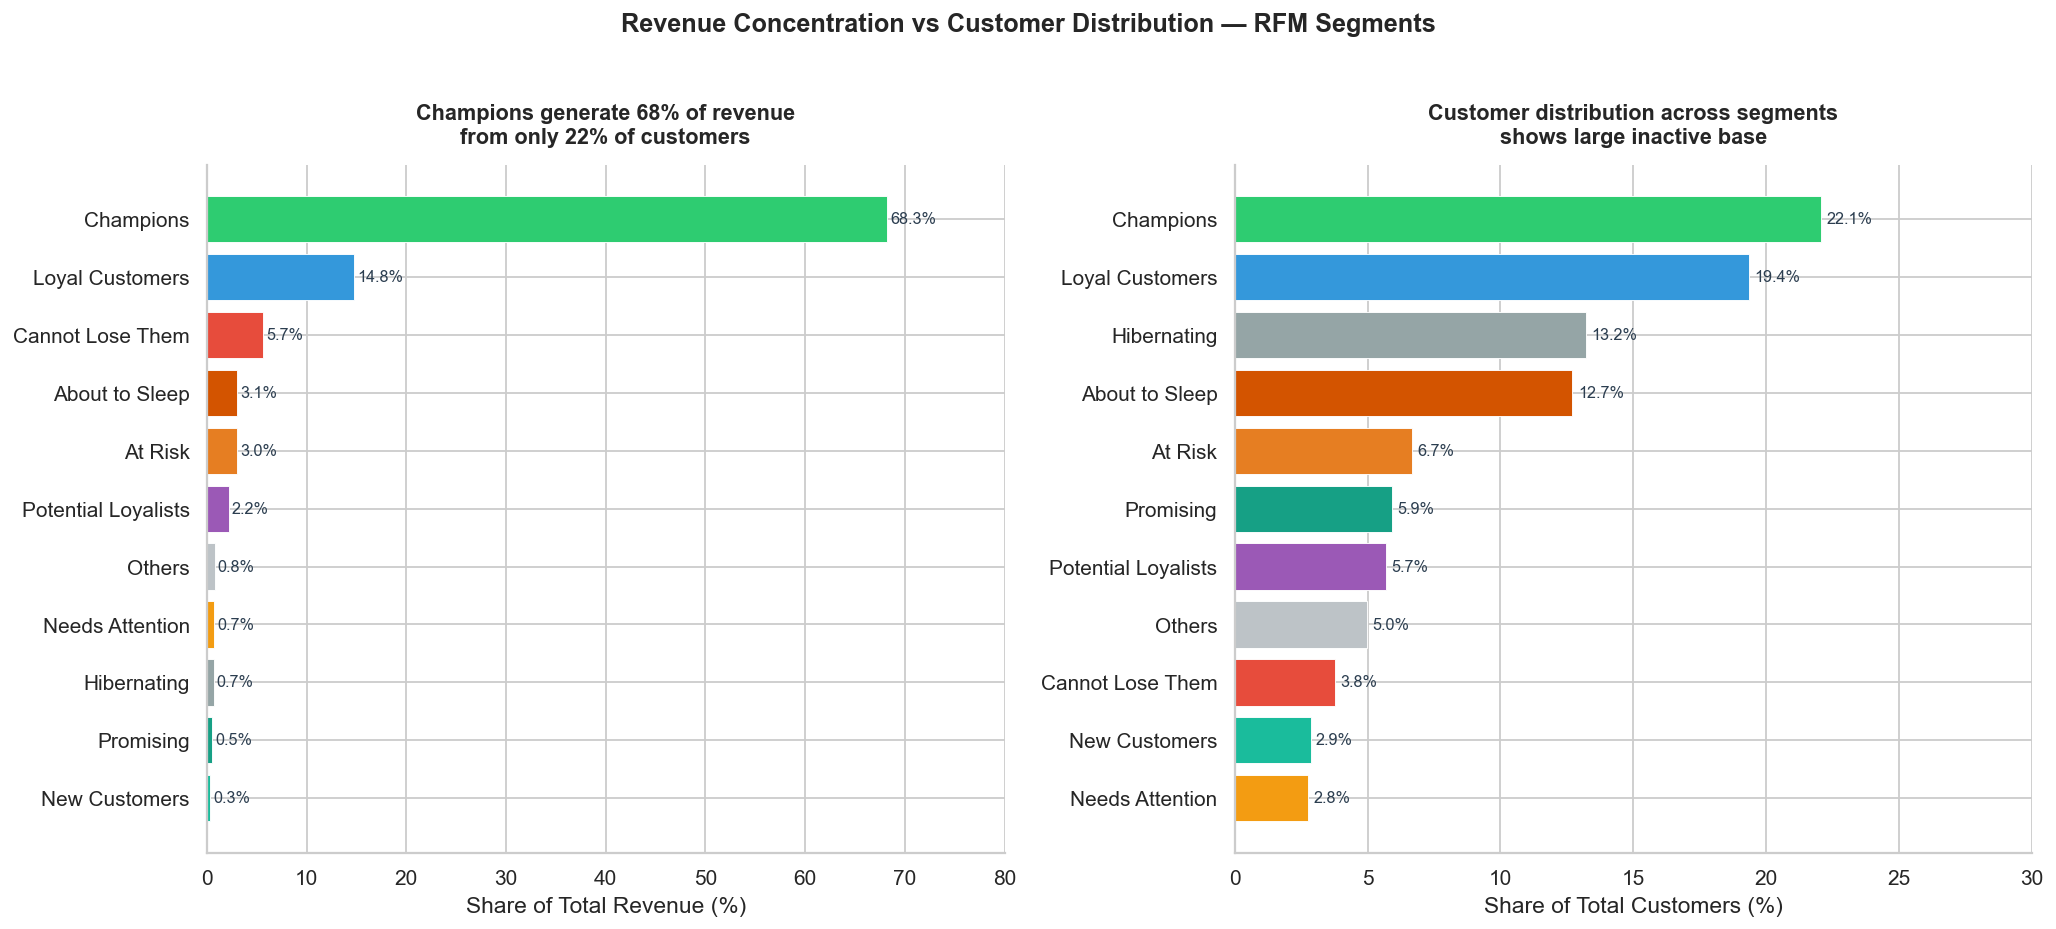

Champions: 22.1% of customers → 68.3% of revenue
Revenue concentration ratio: 3.1x


In [9]:

# Business question: Which segments deliver disproportionate revenue
#                   relative to their customer count?

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Prepare data
seg_summary = rfm.groupby('Segment').agg(
    customers = ('customer_id', 'count'),
    revenue   = ('Monetary', 'sum')
).reset_index()

seg_summary['customer_pct'] = seg_summary['customers'] / seg_summary['customers'].sum() * 100
seg_summary['revenue_pct']  = seg_summary['revenue']   / seg_summary['revenue'].sum()   * 100

# Sort by revenue for consistent ordering
seg_order_rev  = seg_summary.sort_values('revenue_pct', ascending=False)['Segment'].tolist()
seg_order_cust = seg_summary.sort_values('customer_pct', ascending=False)['Segment'].tolist()

bar_colors_rev  = [SEGMENT_COLORS.get(s, '#bdc3c7') for s in seg_order_rev]
bar_colors_cust = [SEGMENT_COLORS.get(s, '#bdc3c7') for s in seg_order_cust]

# Left chart — Revenue share
rev_sorted = seg_summary.sort_values('revenue_pct', ascending=True)
bars = axes[0].barh(
    rev_sorted['Segment'],
    rev_sorted['revenue_pct'],
    color=[SEGMENT_COLORS.get(s, '#bdc3c7') for s in rev_sorted['Segment']],
    edgecolor='white', linewidth=0.5
)
# Add percentage labels on bars
for bar, val in zip(bars, rev_sorted['revenue_pct']):
    axes[0].text(
        val + 0.3, bar.get_y() + bar.get_height()/2,
        f'{val:.1f}%', va='center', fontsize=9, color='#2c3e50'
    )
axes[0].set_title(
    'Champions generate 68% of revenue\nfrom only 22% of customers',
    fontsize=12, fontweight='bold', pad=12
)
axes[0].set_xlabel('Share of Total Revenue (%)')
axes[0].set_ylabel('')
axes[0].set_xlim(0, 80)

# Right chart — Customer share
cust_sorted = seg_summary.sort_values('customer_pct', ascending=True)
bars2 = axes[1].barh(
    cust_sorted['Segment'],
    cust_sorted['customer_pct'],
    color=[SEGMENT_COLORS.get(s, '#bdc3c7') for s in cust_sorted['Segment']],
    edgecolor='white', linewidth=0.5
)
for bar, val in zip(bars2, cust_sorted['customer_pct']):
    axes[1].text(
        val + 0.2, bar.get_y() + bar.get_height()/2,
        f'{val:.1f}%', va='center', fontsize=9, color='#2c3e50'
    )
axes[1].set_title(
    'Customer distribution across segments\nshows large inactive base',
    fontsize=12, fontweight='bold', pad=12
)
axes[1].set_xlabel('Share of Total Customers (%)')
axes[1].set_ylabel('')
axes[1].set_xlim(0, 30)

plt.suptitle(
    'Revenue Concentration vs Customer Distribution — RFM Segments',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
#plt.savefig('dashboard/screenshots/chart1_revenue_vs_customers.png')
plt.show()


champions_rev  = seg_summary[seg_summary['Segment']=='Champions']['revenue_pct'].values[0]
champions_cust = seg_summary[seg_summary['Segment']=='Champions']['customer_pct'].values[0]
print(f"Champions: {champions_cust:.1f}% of customers → {champions_rev:.1f}% of revenue")
print(f"Revenue concentration ratio: {champions_rev/champions_cust:.1f}x")


In [10]:
# Business Overview

# The RFM analysis reveals a highly concentrated revenue structure where a relatively small group of customers drives the majority of the business.
# Champions account for only 22.1% of the customer base but generate 68.3% of total revenue, making them the company's most valuable asset. 
# Together, Champions and Loyal Customers contribute over 83% of total revenue, highlighting the importance of retention and loyalty programs.

# At the same time, the customer distribution chart shows a sizeable inactive population, with Hibernating (13.2%) and About to Sleep (12.7%) 
# segments representing more than one-quarter of all customers. This indicates significant opportunities for reactivation campaigns.

# Overall, the business is performing strongly due to its high-value customers, but it also faces a concentration risk by relying heavily on Champions.
# Protecting these customers while converting inactive and promising segments into loyal buyers should be the primary growth strategy.

#  CHART 2: Distribution of R, F, M scores

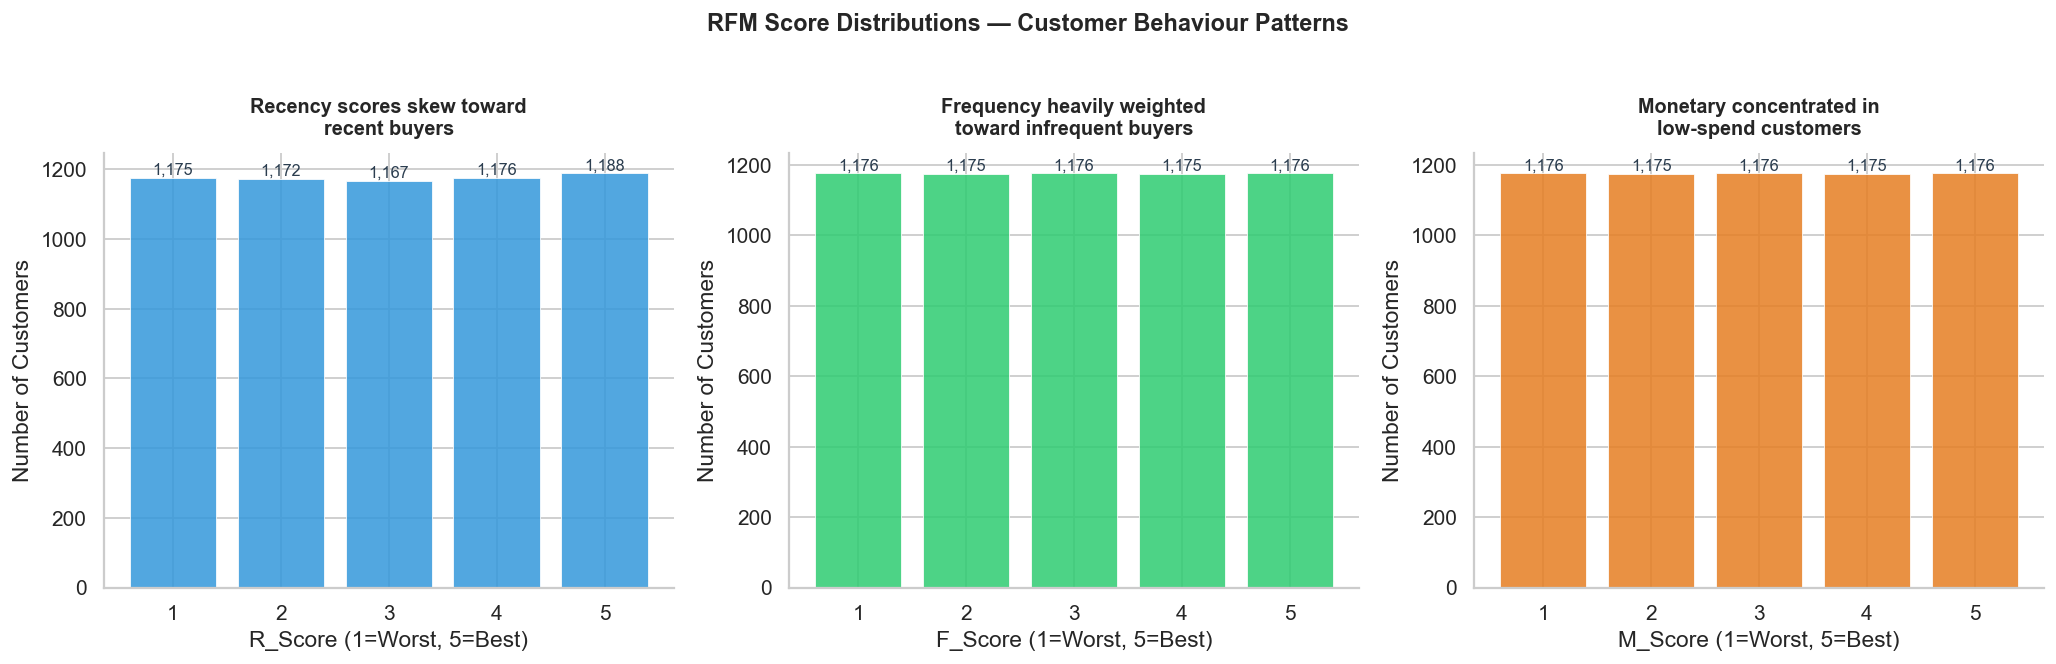

In [11]:

# Business question: Are customers evenly distributed across score levels or concentrated at extremes?

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

score_cols  = ['R_Score', 'F_Score', 'M_Score']
score_titles = [
    'Recency scores skew toward\nrecent buyers',
    'Frequency heavily weighted\ntoward infrequent buyers',
    'Monetary concentrated in\nlow-spend customers'
]
colors_scores = ['#3498db', '#2ecc71', '#e67e22']

for i, (col, title, color) in enumerate(zip(score_cols, score_titles, colors_scores)):
    counts = rfm[col].value_counts().sort_index()
    bars   = axes[i].bar(
        counts.index, counts.values,
        color=color, edgecolor='white', linewidth=0.5, alpha=0.85
    )
    # Add count labels on top of each bar
    for bar, val in zip(bars, counts.values):
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 10,
            f'{val:,}', ha='center', fontsize=9, color='#2c3e50'
        )
    axes[i].set_title(title, fontsize=11, fontweight='bold', pad=10)
    axes[i].set_xlabel(f'{col} (1=Worst, 5=Best)')
    axes[i].set_ylabel('Number of Customers')
    axes[i].set_xticks([1, 2, 3, 4, 5])

plt.suptitle(
    'RFM Score Distributions — Customer Behaviour Patterns',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()




In [12]:
# Business Overview

# The RFM score distributions show that customers are evenly distributed across all five score levels for Recency, Frequency, and Monetary,
# with each score containing approximately 1,175 customers. This balanced distribution indicates that the quantile-based RFM scoring model
# has segmented the customer base effectively without creating heavily skewed groups.

# Customers are fairly evenly distributed across all RFM score levels, confirming that the scoring methodology creates balanced and meaningful
# customer segments rather than concentrating customers at the extremes.

# CHART 3: Recency vs Monetary scatter by segment

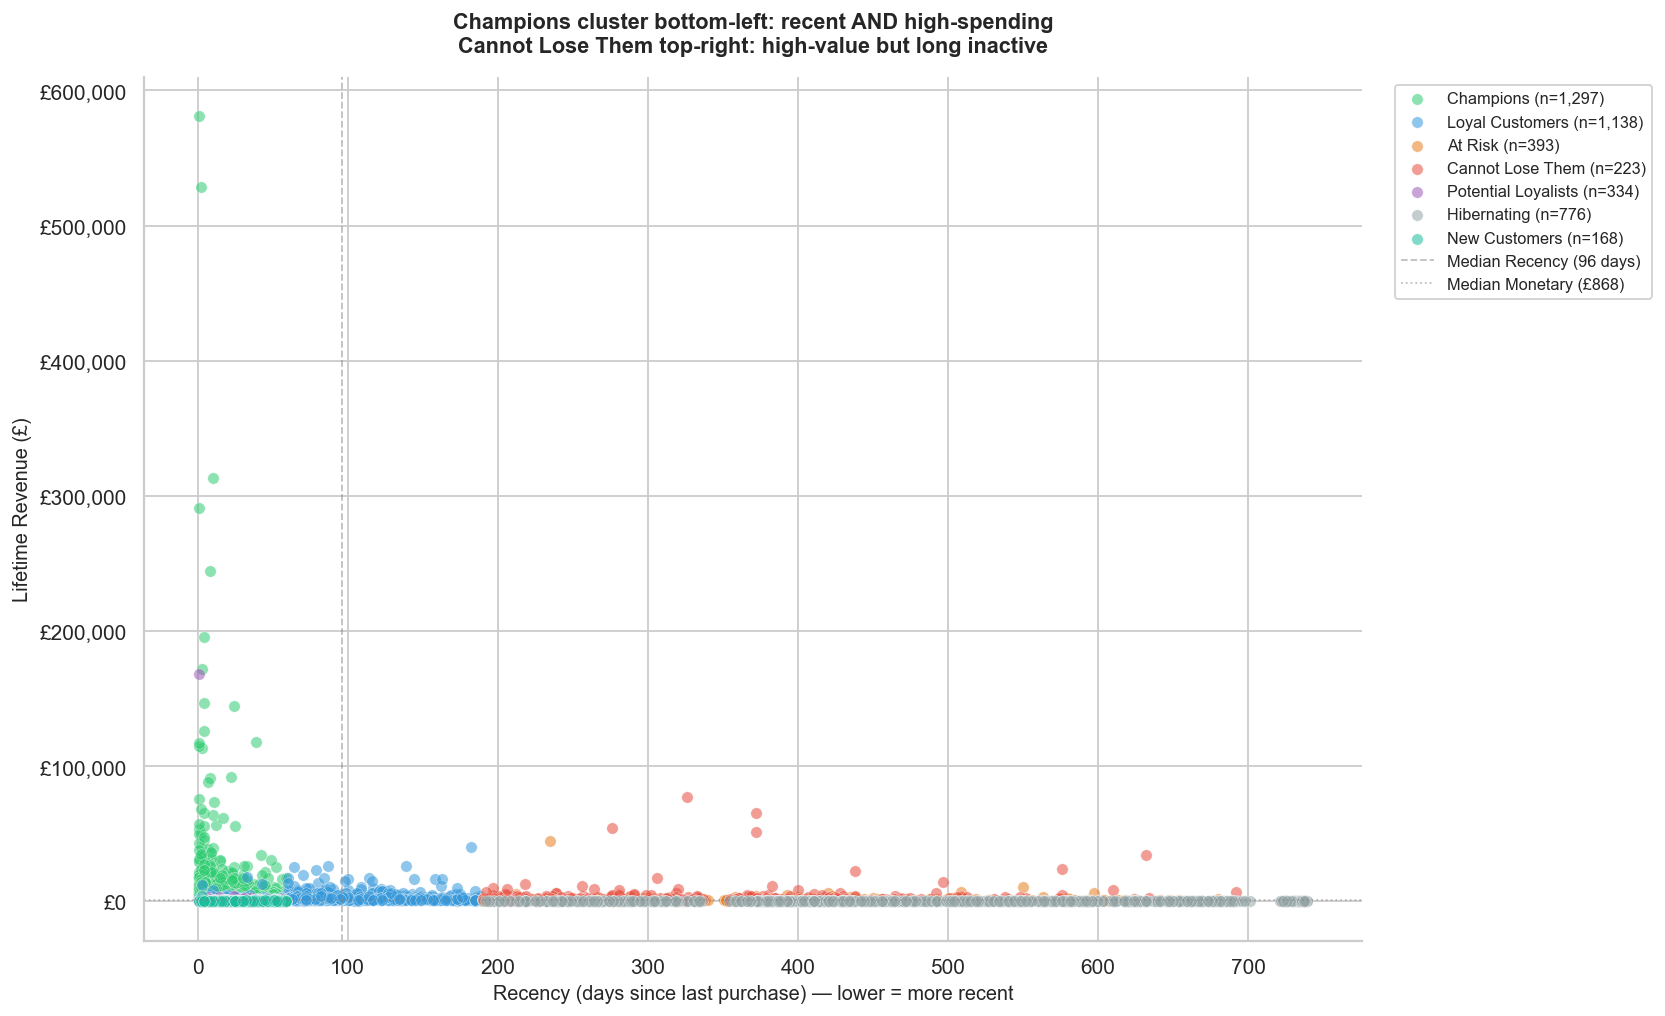

In [13]:

# Business question: Do high-value customers also tend to be recent buyers,
#                   and where do at-risk segments cluster?

fig, ax = plt.subplots(figsize=(13, 8))

# Plot each segment separately to control colour and legend
segments_to_plot = [
    'Champions', 'Loyal Customers', 'At Risk',
    'Cannot Lose Them', 'Potential Loyalists',
    'Hibernating', 'New Customers'
]

for segment in segments_to_plot:
    data = rfm[rfm['Segment'] == segment]
    ax.scatter(
        data['Recency'],
        data['Monetary'],
        c=SEGMENT_COLORS.get(segment, '#bdc3c7'),
        label=f"{segment} (n={len(data):,})",
        alpha=0.55,
        s=40,
        edgecolors='white',
        linewidth=0.3
    )

# Reference lines
median_recency  = rfm['Recency'].median()
median_monetary = rfm['Monetary'].median()
ax.axvline(median_recency,  color='grey', linestyle='--',
           alpha=0.5, linewidth=1, label=f'Median Recency ({median_recency:.0f} days)')
ax.axhline(median_monetary, color='grey', linestyle=':',
           alpha=0.5, linewidth=1, label=f'Median Monetary (£{median_monetary:,.0f})')

ax.set_title(
    'Champions cluster bottom-left: recent AND high-spending\n'
    'Cannot Lose Them top-right: high-value but long inactive',
    fontsize=12, fontweight='bold', pad=14
)
ax.set_xlabel('Recency (days since last purchase) — lower = more recent', fontsize=11)
ax.set_ylabel('Lifetime Revenue (£)', fontsize=11)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.tight_layout()
plt.show()



In [14]:
# Business Overview

# This visualization highlights a strong relationship between customer recency and customer value. The most valuable and active customers (Champions) 
# are concentrated in the lower-left area of the chart, indicating that they have purchased recently and generated high lifetime revenue. 
# In contrast, the Cannot Lose Them and At Risk segments are positioned further to the right, showing that many high-value customers have 
# not purchased for a long time.

# The chart clearly demonstrates that while the business has a loyal core of active high spenders, it also has a significant group of previously 
# valuable customers who are becoming inactive. This presents a major opportunity for targeted retention and win-back campaigns.

# CHART 4: Monthly revenue trend with annotations

In [15]:

# Business question: Is revenue growing over time and what seasonal
#                   patterns exist?

orders_clean = orders.copy()
orders_clean['month'] = orders_clean['invoicedate'].dt.to_period('M')

monthly = orders_clean.groupby('month').agg(
    revenue   = ('revenue', 'sum'),
    customers = ('customer_id', 'nunique'),
    orders_ct = ('invoice', 'nunique')
).reset_index()

monthly['month_dt'] = monthly['month'].dt.to_timestamp()
monthly['mom_growth'] = monthly['revenue'].pct_change() * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Top — Revenue line
axes[0].plot(
    monthly['month_dt'], monthly['revenue'],
    color='#2563eb', linewidth=2.5, marker='o', markersize=5
)
axes[0].fill_between(
    monthly['month_dt'], monthly['revenue'],
    alpha=0.08, color='#2563eb'
)

# Add reference average line
avg_rev = monthly['revenue'].mean()
axes[0].axhline(
    avg_rev, color='#e74c3c', linestyle='--',
    linewidth=1.2, alpha=0.7,
    label=f'Monthly avg: £{avg_rev:,.0f}'
)

# Annotate peak month
peak_idx = monthly['revenue'].idxmax()
peak_row = monthly.loc[peak_idx]
axes[0].annotate(
    f"Peak: £{peak_row['revenue']:,.0f}",
    xy=(peak_row['month_dt'], peak_row['revenue']),
    xytext=(0, 14), textcoords='offset points',
    ha='center', fontsize=9, color='#2c3e50',
    arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=1.2)
)

axes[0].set_title(
    'Revenue peaks in Q4 each year — strong seasonal pattern\nindicates holiday-driven demand',
    fontsize=12, fontweight='bold'
)
axes[0].set_ylabel('Monthly Revenue (£)')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M')
)
axes[0].legend(fontsize=9)

# Bottom — MoM growth bars
colors_growth = ['#2ecc71' if x >= 0 else '#e74c3c'
                 for x in monthly['mom_growth'].fillna(0)]
axes[1].bar(
    monthly['month_dt'], monthly['mom_growth'].fillna(0),
    color=colors_growth, edgecolor='white', linewidth=0.3, width=20
)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title(
    'Month-over-month revenue growth — green = growth, red = decline',
    fontsize=11, fontweight='bold'
)
axes[1].set_ylabel('MoM Growth (%)')
axes[1].set_xlabel('Month')

plt.suptitle(
    'Monthly Revenue Trend — Dec 2009 to Dec 2011',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

# Print key metrics
print(f"Peak month:    {peak_row['month']} — £{peak_row['revenue']:,.0f}")
print(f"Monthly avg:   £{avg_rev:,.0f}")
print(f"Best growth:   {monthly['mom_growth'].max():.1f}%")
print(f"Worst decline: {monthly['mom_growth'].min():.1f}%")


AttributeError: Can only use .dt accessor with datetimelike values

In [ ]:
# Business Overview

# The monthly revenue trend shows that the business experiences a clear seasonal pattern, with sales consistently peaking during the
# holiday period. The highest monthly revenue reached £1.16 million, significantly above the overall monthly average of £694,992,
# indicating strong customer demand during year-end shopping seasons.

# Month-over-month growth is volatile, with the business achieving a maximum growth rate of +47.2%, while the largest decline was 
# approximately -50.7% immediately after the holiday peak. 
# This suggests that revenue is heavily influenced by seasonal buying behaviour rather than steady year-round growth.

# Overall, the company maintains an average monthly revenue of nearly £695K, but its strongest performance depends on successfully
# capitalizing on the high-demand period.
# Strategic inventory planning and marketing campaigns before the holiday season could maximize this opportunity, 
# while retention initiatives after the peak could help reduce the sharp post-season decline.

#  CHART 5: Correlation heatmap

In [ ]:

# Business question: Which RFM dimensions are most strongly related
#                   to each other?

fig, ax = plt.subplots(figsize=(9, 7))

corr_cols = ['Recency', 'Frequency', 'Monetary',
             'avg_order_value', 'tenure_days', 'unique_products']
corr_matrix = rfm[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)

ax.set_title(
    'Frequency and Monetary strongly correlated (0.7+)\n'
    'Customers who buy often also spend more',
    fontsize=12, fontweight='bold', pad=14
)

plt.tight_layout()
plt.show()

# Extract key correlations
freq_mon_corr = corr_matrix.loc['Frequency', 'Monetary']
rec_mon_corr  = corr_matrix.loc['Recency',   'Monetary']
print(f"Frequency vs Monetary correlation: {freq_mon_corr:.3f}")
print(f"Recency vs Monetary correlation:   {rec_mon_corr:.3f}")
print()
if freq_mon_corr > 0.5:
    print("Strong positive correlation — frequent buyers spend more.")
    print("Business implication: increasing purchase frequency")
    print("is the fastest route to increasing customer lifetime value.")



In [ ]:
# Business Overview

# The correlation analysis shows that purchase frequency is the strongest driver of customer value. Frequency and Monetary have a strong 
# positive correlation of 0.63, meaning customers who buy more often also tend to generate higher lifetime revenue. Similarly, Frequency 
# and Unique Products are highly correlated (0.69), suggesting that engaged customers purchase a wider variety of products.

# Recency has a moderate negative relationship with Tenure (-0.56) and a weaker negative relationship with Frequency (-0.26), 
# indicating that customers who have not purchased recently are generally less active. Interestingly, Average Order Value has very 
# little correlation with the other metrics, implying that increasing purchase frequency may be more effective than simply trying to 
# increase basket size.

# Overall, the data suggests that encouraging repeat purchases is the fastest path to increasing customer lifetime value.

# CHART 6: Revenue at risk visualisation 

In [ ]:

# Business question: How much revenue is at risk and how does it
#                   compare to safe revenue?

# Classify revenue by risk level
risk_map = {
    'Champions':          'Protected',
    'Loyal Customers':    'Protected',
    'Potential Loyalists':'Growth opportunity',
    'New Customers':      'Growth opportunity',
    'Promising':          'Growth opportunity',
    'At Risk':            'At Risk',
    'Cannot Lose Them':   'At Risk',
    'Needs Attention':    'Watch',
    'About to Sleep':     'Watch',
    'Hibernating':        'Low priority',
    'Others':             'Low priority'
}

rfm['risk_tier'] = rfm['Segment'].map(risk_map)

risk_summary = rfm.groupby('risk_tier').agg(
    customers = ('customer_id', 'count'),
    revenue   = ('Monetary', 'sum')
).reset_index()

risk_summary['revenue_pct'] = risk_summary['revenue'] / risk_summary['revenue'].sum() * 100

risk_colors = {
    'Protected':          '#2ecc71',
    'At Risk':            '#e74c3c',
    'Growth opportunity': '#3498db',
    'Watch':              '#e67e22',
    'Low priority':       '#95a5a6'
}

# Sort by revenue
risk_summary = risk_summary.sort_values('revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — Revenue by risk tier
bars = axes[0].bar(
    risk_summary['risk_tier'],
    risk_summary['revenue'],
    color=[risk_colors.get(t, '#bdc3c7') for t in risk_summary['risk_tier']],
    edgecolor='white', linewidth=0.5
)
for bar, pct in zip(bars, risk_summary['revenue_pct']):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50000,
        f'{pct:.1f}%',
        ha='center', fontsize=10, fontweight='bold'
    )
axes[0].set_title(
    'Protected revenue vs at-risk revenue\nChampions and Loyal = safe core',
    fontsize=11, fontweight='bold'
)
axes[0].set_ylabel('Total Revenue (£)')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M')
)
axes[0].tick_params(axis='x', rotation=20)

# Right — Customers by risk tier
bars2 = axes[1].bar(
    risk_summary['risk_tier'],
    risk_summary['customers'],
    color=[risk_colors.get(t, '#bdc3c7') for t in risk_summary['risk_tier']],
    edgecolor='white', linewidth=0.5
)
for bar, val in zip(bars2, risk_summary['customers']):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        f'{val:,}',
        ha='center', fontsize=10
    )
axes[1].set_title(
    'Customer count by risk tier\nLarge inactive base with low revenue impact',
    fontsize=11, fontweight='bold'
)
axes[1].set_ylabel('Number of Customers')
axes[1].tick_params(axis='x', rotation=20)

# Add total at-risk annotation
at_risk_rev = risk_summary[risk_summary['risk_tier']=='At Risk']['revenue'].sum()
at_risk_pct = risk_summary[risk_summary['risk_tier']=='At Risk']['revenue_pct'].sum()
fig.text(
    0.5, -0.04,
    f'Total revenue at risk: £{at_risk_rev:,.0f} ({at_risk_pct:.1f}% of total)',
    ha='center', fontsize=11, color='#e74c3c', fontweight='bold'
)

plt.suptitle(
    'Revenue Risk Assessment by Customer Tier',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()



In [ ]:
# Business Overview

# The revenue risk analysis shows that the business has a strong and stable customer base, with Protected customers (Champions and Loyal Customers) 
# contributing approximately £14.4M, or 83.0% of total revenue, while representing 2,435 customers. This indicates that the majority of business
# performance depends on a relatively engaged and loyal customer segment.

# However, around £1.5M (8.7%) of revenue is currently at risk, coming from 616 At Risk and Cannot Lose Them customers. 
# Although this group is relatively small, it contains many historically valuable customers who could significantly impact revenue if not retained.

# The business also has a sizeable pool of future opportunities, with 850 Growth Opportunity customers and 909 Watch custome
# together contributing nearly 7% of total revenue. Meanwhile, the 1,068 Low Priority customers generate only 1.5% of revenue, 
# suggesting that retention resources should focus primarily on higher-value segments.

# CHART 7: Spending distribution within each segment

In [ ]:

# Business question: How consistent is spending within each segment,
#                   and where are the outliers?

# Focus on key segments for readability
key_segments = [
    'Champions', 'Loyal Customers', 'At Risk',
    'Cannot Lose Them', 'Potential Loyalists', 'Hibernating'
]
rfm_key = rfm[rfm['Segment'].isin(key_segments)].copy()

fig, ax = plt.subplots(figsize=(13, 7))

segment_order = rfm_key.groupby('Segment')['Monetary'] \
                        .median().sort_values(ascending=False).index.tolist()

sns.boxplot(
    data=rfm_key,
    x='Segment',
    y='Monetary',
    order=segment_order,
    palette={s: SEGMENT_COLORS.get(s, '#bdc3c7') for s in segment_order},
    width=0.5,
    fliersize=3,
    ax=ax
)

ax.set_title(
    'Champions show highest median spend with widest variance\n'
    'Hibernating customers clustered near zero lifetime value',
    fontsize=12, fontweight='bold', pad=14
)
ax.set_xlabel('')
ax.set_ylabel('Lifetime Revenue (£)')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Print median values for your observation
print("Median lifetime revenue by segment:")
print(rfm_key.groupby('Segment')['Monetary'].median()
             .sort_values(ascending=False)
             .apply(lambda x: f'£{x:,.2f}'))


In [ ]:
# Business Overview

# The spending distribution analysis reveals significant differences in customer value across RFM segments. Champions have the highest median 
# lifetime revenue and the widest spending range, with several customers generating over £500,000 in lifetime value. 
# This indicates that the business relies heavily on a small group of exceptionally valuable customers.

# Loyal Customers and Cannot Lose Them also contribute substantial revenue, but their spending is more concentrated and less variable than Champions. 
# The presence of high-value outliers within the Cannot Lose Them segment highlights an important retention opportunity, as losing even a few of 
# these customers could have a noticeable financial impact.

# On the other hand, Potential Loyalists, At Risk, and Hibernating customers are clustered at much lower spending levels, with Hibernating 
# customers contributing minimal lifetime value overall.

# EDA SUMMARY

In [ ]:

print("=" * 55)
print("DAY 7 EDA SUMMARY")
print("=" * 55)
print(f"Charts produced:        7")
print(f"Charts saved to:        dashboard/screenshots/")
print()
print("Key visual findings:")
print(f"  Champions revenue share:  {champions_rev:.1f}%")
print(f"  Revenue at risk:          {at_risk_pct:.1f}%")
print(f"  Peak revenue month:       {peak_row['month']}")
print()
print("Charts ready for Power BI dashboard:")
print("  chart1_revenue_vs_customers.png")
print("  chart2_rfm_distributions.png")
print("  chart3_recency_monetary_scatter.png")
print("  chart4_monthly_revenue_trend.png")
print("  chart5_correlation_heatmap.png")
print("  chart6_revenue_risk.png")
print("  chart7_monetary_boxplot.png")



In [ ]:
# Overall EDA Conclusion

# The exploratory analysis reveals that the business has a strong but concentrated customer base. 
# Champions and Loyal Customers contribute the majority of revenue, while a relatively small group of high-value inactive customers 
# represents a significant retention opportunity.

# Key findings from the analysis include:

# 22.1% of customers (Champions) generate 68.3% of total revenue.
# Protected segments contribute 83% of overall revenue, indicating a stable core customer base.
# Approximately £1.5M (8.7%) of revenue is currently at risk from inactive high-value customers.
# Revenue follows a clear seasonal pattern, with generating the highest sales.
# Customer lifetime value is driven primarily by purchase frequency, as Frequency and Monetary show a strong positive correlation (0.63).
# Spending behavior varies significantly across segments, validating the effectiveness of the RFM segmentation model.

# Overall, the analysis suggests that the business should focus on:

# Retaining Champion and Loyal customers.
# Running targeted win-back campaigns for "Cannot Lose Them" and "At Risk" customers.
# Converting Potential Loyalists into long-term high-value customers.
# Leveraging seasonal demand through proactive marketing and inventory planning.
